### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [2]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home"
os.environ.setdefault("JAVA_TOOL_OPTIONS", "-Djava.security.manager=allow")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [3]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


Picked up JAVA_TOOL_OPTIONS: -Djava.security.manager=allow
Picked up JAVA_TOOL_OPTIONS: -Djava.security.manager=allow
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/07 17:40:01 WARN Utils: Your hostname, MacBook-Pro-Mateusz-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.3 instead (on interface en0)
26/06/07 17:40:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/07 17:40:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [7]:
import kagglehub

path = kagglehub.dataset_download("szymoncyperski/car-sales-offers-from-otomotopl-2023")

print("Path to dataset files:", path)

df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv(path)


Path to dataset files: /Users/mateuszadamczyk/.cache/kagglehub/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023/versions/1


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [8]:
df.show()

26/06/07 17:42:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [9]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [10]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [11]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [12]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka


+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [13]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [14]:
df.createOrReplaceTempView("cars")

In [15]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [16]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [17]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [18]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


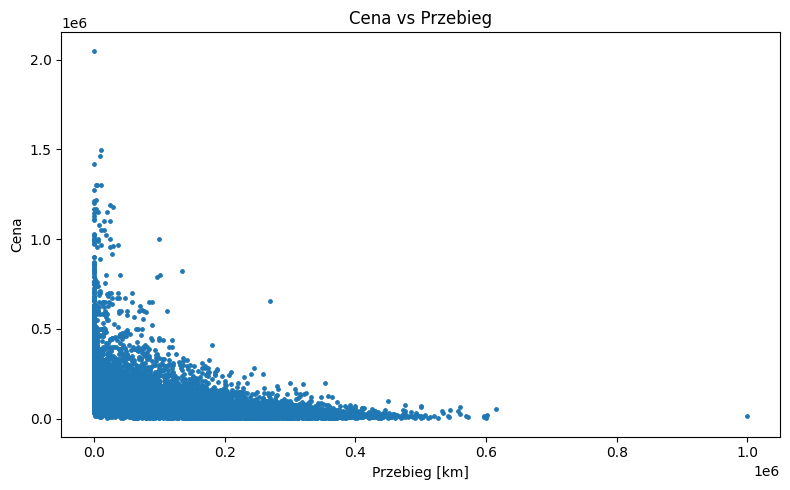

In [20]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [ ]:
from pathlib import Path

from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder

candidate_paths = [
    Path("chicago_crimes_sample.csv"),
    Path("materialy/lab_05/chicago_crimes_sample.csv"),
]

csv_path = next((str(p) for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Nie znaleziono chicago_crimes_sample.csv w oczekiwanych lokalizacjach")

crimes_raw = (
    spark.read
    .option("header", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("inferSchema", False)
    .csv(csv_path)
)

def classify_day_part(hour):
    if hour is None:
        return None
    if 5 <= hour < 12:
        return "morning"
    if 12 <= hour < 17:
        return "day"
    if 17 <= hour < 22:
        return "evening"
    return "night"

day_part_udf = F.udf(classify_day_part, StringType())

crimes_clean = (
    crimes_raw
    .withColumn(
        "date_ts",
        F.coalesce(
            F.to_timestamp(F.col("date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"),
            F.to_timestamp(F.col("date"))
        )
    )
    .withColumn("Year", F.year(F.col("date_ts")))
    .withColumn("Month", F.month(F.col("date_ts")))
    .withColumn("Hour", F.hour(F.col("date_ts")))
    .withColumn("day_part", day_part_udf(F.col("Hour")))
    .withColumn("arrest_int", F.when(F.lower(F.col("arrest")) == "true", F.lit(1)).otherwise(F.lit(0)))
    .withColumn("domestic_int", F.when(F.lower(F.col("domestic")) == "true", F.lit(1)).otherwise(F.lit(0)))
    .dropDuplicates(["id"])
    .filter(F.col("date_ts").isNotNull())
    .filter(
        F.col("id").isNotNull() & (F.trim(F.col("id")) != "") &
        F.col("case_number").isNotNull() & (F.trim(F.col("case_number")) != "") &
        F.col("primary_type").isNotNull() & (F.trim(F.col("primary_type")) != "") &
        F.col("location_description").isNotNull() & (F.trim(F.col("location_description")) != "") &
        F.col("Year").isNotNull()
    )
    .cache()
)

crimes_clean.count()

day_part_lookup = spark.createDataFrame(
    [
        ("night", 1),
        ("morning", 2),
        ("day", 3),
        ("evening", 4),
    ],
    ["day_part", "day_part_order"]
)

crimes_enriched = (
    crimes_clean
    .join(F.broadcast(day_part_lookup), on="day_part", how="left")
    .cache()
)

crimes_enriched.count()

output_path = "output/chicago_crimes_parquet"
(
    crimes_enriched
    .write
    .mode("overwrite")
    .partitionBy("Year")
    .parquet(output_path)
)

print(f"Zapisano Parquet do: {output_path}")

top_primary_types = (
    crimes_enriched
    .groupBy("primary_type")
    .count()
    .orderBy(F.desc("count"))
)

print("Najczęstsze typy przestępstw")
top_primary_types.show(15, truncate=False)

top_by_location_and_time = (
    crimes_enriched
    .groupBy("location_description", "primary_type", "day_part")
    .count()
    .orderBy(F.desc("count"))
)

print("Plan zapytania dla ciężkiej agregacji")
top_by_location_and_time.explain(True)

print("Najpopularniejsze typy przestępstw w lokacjach i porach dnia")
top_by_location_and_time.show(20, truncate=False)

arrest_rate_by_type = (
    crimes_enriched
    .groupBy("primary_type")
    .agg(
        F.count(F.lit(1)).alias("total_cases"),
        F.round(F.avg("arrest_int") * 100, 2).alias("arrest_rate_pct")
    )
    .orderBy(F.desc("total_cases"))
)

arrest_rate_by_type.show(15, truncate=False)

hourly_hotspots = (
    crimes_enriched
    .groupBy("Hour", "district")
    .count()
    .orderBy(F.desc("count"))
)

hourly_hotspots.show(20, truncate=False)

ml_df = (
    crimes_enriched
    .select(
        "primary_type",
        F.col("Year").cast("double").alias("Year"),
        F.col("Month").cast("double").alias("Month"),
        F.col("Hour").cast("double").alias("Hour"),
        F.col("arrest_int").cast("double").alias("arrest_int"),
        F.col("domestic_int").cast("double").alias("domestic_int"),
        F.col("district").cast("string").alias("district"),
        F.col("community_area").cast("string").alias("community_area"),
        F.col("location_description").cast("string").alias("location_description"),
        F.col("day_part").cast("string").alias("day_part"),
    )
    .na.drop()
)

label_indexer = StringIndexer(inputCol="primary_type", outputCol="label", handleInvalid="keep")
district_indexer = StringIndexer(inputCol="district", outputCol="district_idx", handleInvalid="keep")
community_indexer = StringIndexer(inputCol="community_area", outputCol="community_area_idx", handleInvalid="keep")
location_indexer = StringIndexer(inputCol="location_description", outputCol="location_description_idx", handleInvalid="keep")
day_part_indexer = StringIndexer(inputCol="day_part", outputCol="day_part_idx", handleInvalid="keep")

district_encoder = OneHotEncoder(inputCols=["district_idx"], outputCols=["district_vec"], handleInvalid="keep")
community_encoder = OneHotEncoder(inputCols=["community_area_idx"], outputCols=["community_area_vec"], handleInvalid="keep")
location_encoder = OneHotEncoder(inputCols=["location_description_idx"], outputCols=["location_description_vec"], handleInvalid="keep")
day_part_encoder = OneHotEncoder(inputCols=["day_part_idx"], outputCols=["day_part_vec"], handleInvalid="keep")

feature_cols = [
    "Year",
    "Month",
    "Hour",
    "arrest_int",
    "domestic_int",
    "district_vec",
    "community_area_vec",
    "location_description_vec",
    "day_part_vec",
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

classifier = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.0,
    family="multinomial"
)

pipeline = Pipeline(
    stages=[
        label_indexer,
        district_indexer,
        community_indexer,
        location_indexer,
        day_part_indexer,
        district_encoder,
        community_encoder,
        location_encoder,
        day_part_encoder,
        assembler,
        classifier,
    ]
)

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_df)
predictions = model.transform(test_df)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print(f"Accuracy modelu wieloklasowego: {accuracy:.4f}")
predictions.select("primary_type", "prediction", "probability").show(10, truncate=False)

26/06/07 17:49:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/06/07 17:49:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


Zapisano Parquet do: materialy/lab_05/output/chicago_crimes_parquet
Najczęstsze typy przestępstw


+--------------------------+-----+
|primary_type              |count|
+--------------------------+-----+
|THEFT                     |10920|
|BATTERY                   |9253 |
|CRIMINAL DAMAGE           |5497 |
|ASSAULT                   |4564 |
|MOTOR VEHICLE THEFT       |3886 |
|OTHER OFFENSE             |3459 |
|BURGLARY                  |3163 |
|DECEPTIVE PRACTICE        |2486 |
|NARCOTICS                 |1455 |
|CRIMINAL TRESPASS         |1193 |
|WEAPONS VIOLATION         |1022 |
|ROBBERY                   |916  |
|OFFENSE INVOLVING CHILDREN|368  |
|CRIMINAL SEXUAL ASSAULT   |331  |
|SEX OFFENSE               |306  |
+--------------------------+-----+
only showing top 15 rows
Plan zapytania dla ciężkiej agregacji
== Parsed Logical Plan ==
'Sort ['count DESC NULLS LAST], true
+- Aggregate [location_description#3378, primary_type#3376, day_part#3399], [location_description#3378, primary_type#3376, day_part#3399, count(1) AS count#7376L]
   +- Project [day_part#3399, id#3371, case_nu

+--------------------+-------------------+--------+-----+
|location_description|primary_type       |day_part|count|
+--------------------+-------------------+--------+-----+
|STREET              |MOTOR VEHICLE THEFT|night   |992  |
|APARTMENT           |BATTERY            |night   |971  |
|STREET              |MOTOR VEHICLE THEFT|evening |922  |
|STREET              |CRIMINAL DAMAGE    |night   |795  |
|APARTMENT           |BATTERY            |evening |773  |
|APARTMENT           |BATTERY            |morning |679  |
|STREET              |THEFT              |night   |666  |
|STREET              |THEFT              |evening |634  |
|APARTMENT           |BATTERY            |day     |596  |
|STREET              |THEFT              |morning |568  |
|STREET              |MOTOR VEHICLE THEFT|morning |567  |
|APARTMENT           |THEFT              |day     |519  |
|STREET              |BURGLARY           |night   |501  |
|STREET              |CRIMINAL DAMAGE    |evening |494  |
|SMALL RETAIL 

+--------------------------+-----------+---------------+
|primary_type              |total_cases|arrest_rate_pct|
+--------------------------+-----------+---------------+
|THEFT                     |10920      |9.09           |
|BATTERY                   |9253       |18.03          |
|CRIMINAL DAMAGE           |5497       |4.6            |
|ASSAULT                   |4564       |12.84          |
|MOTOR VEHICLE THEFT       |3886       |3.86           |
|OTHER OFFENSE             |3459       |15.29          |
|BURGLARY                  |3163       |2.69           |
|DECEPTIVE PRACTICE        |2486       |2.41           |
|NARCOTICS                 |1455       |93.06          |
|CRIMINAL TRESPASS         |1193       |34.45          |
|WEAPONS VIOLATION         |1022       |73.78          |
|ROBBERY                   |916        |6.33           |
|OFFENSE INVOLVING CHILDREN|368        |7.07           |
|CRIMINAL SEXUAL ASSAULT   |331        |1.21           |
|SEX OFFENSE               |306

+----+--------+-----+
|Hour|district|count|
+----+--------+-----+
|15  |001     |207  |
|0   |004     |202  |
|12  |001     |195  |
|16  |001     |193  |
|18  |012     |193  |
|0   |019     |192  |
|0   |008     |191  |
|17  |012     |190  |
|15  |008     |188  |
|16  |019     |186  |
|13  |001     |185  |
|0   |006     |183  |
|15  |019     |181  |
|17  |008     |181  |
|12  |019     |180  |
|0   |012     |178  |
|17  |001     |176  |
|16  |003     |174  |
|19  |012     |174  |
|12  |012     |174  |
+----+--------+-----+
only showing top 20 rows


26/06/07 17:49:49 ERROR Instrumentation: java.lang.IllegalArgumentException: requirement failed: DecisionTree requires maxBins (= 32) to be at least as large as the number of values in each categorical feature, but categorical feature 7 has 106 values. Consider removing this and other categorical features with a large number of values, or add more training examples.
	at scala.Predef$.require(Predef.scala:337)
	at org.apache.spark.ml.tree.impl.DecisionTreeMetadata$.buildMetadata(DecisionTreeMetadata.scala:153)
	at org.apache.spark.ml.tree.impl.RandomForest$.run(RandomForest.scala:303)
	at org.apache.spark.ml.classification.RandomForestClassifier.$anonfun$train$1(RandomForestClassifier.scala:168)
	at org.apache.spark.ml.util.Instrumentation$.$anonfun$instrumented$1(Instrumentation.scala:226)
	at scala.util.Try$.apply(Try.scala:217)
	at org.apache.spark.ml.util.Instrumentation$.instrumented(Instrumentation.scala:226)
	at org.apache.spark.ml.classification.RandomForestClassifier.train(Rand

IllegalArgumentException: requirement failed: DecisionTree requires maxBins (= 32) to be at least as large as the number of values in each categorical feature, but categorical feature 7 has 106 values. Consider removing this and other categorical features with a large number of values, or add more training examples.